In [2]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import jax.scipy.optimize


## A. Data Ingestion and Time-to-Failure Extraction

In [3]:
# load dataset
df = pd.read_csv(
    "../data/raw/cmapss/train_FD001.txt",
    sep="\s+",
    header=None,
    names=[
        "unit",
        "cycle",
        "setting1",
        "setting2",
        "setting3",
        "s1",
        "s2",
        "s3",
        "s4",
        "s5",
        "s6",
        "s7",
        "s8",
        "s9",
        "s10",
        "s11",
        "s12",
        "s13",
        "s14",
        "s15",
        "s16",
        "s17",
        "s18",
        "s19",
        "s20",
        "s21",
    ],
)

df.head()

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/var/folders/x6/99wzjbqn14s9nxx1j_1l1qkm0000gn/T/ipykernel_47328/1433004349.py:4: SyntaxWarning: invalid escape sequence '\s'
  sep="\s+",


,unit,cycle,setting1,setting2,setting3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [4]:
# extract time-to-failure
time_to_failure = df.groupby("unit")["cycle"].max()
print("Failure Times: ")
print(time_to_failure)

Failure Times: 
unit
1      192
2      287
3      179
4      189
5      269
      ... 
96     336
97     202
98     156
99     185
100    200
Name: cycle, Length: 100, dtype: int64


In [5]:
# failure times
print("Failure Times: ")
print("\nMean: ")
print(time_to_failure.mean())
print("\nMedian: ")
print(time_to_failure.median())
print("\nMinumum: ")
print(time_to_failure.min())
print("\nMaximum: ")
print(time_to_failure.max())

Failure Times: 

Mean: 
206.31

Median: 
199.0

Minumum: 
128

Maximum: 
362


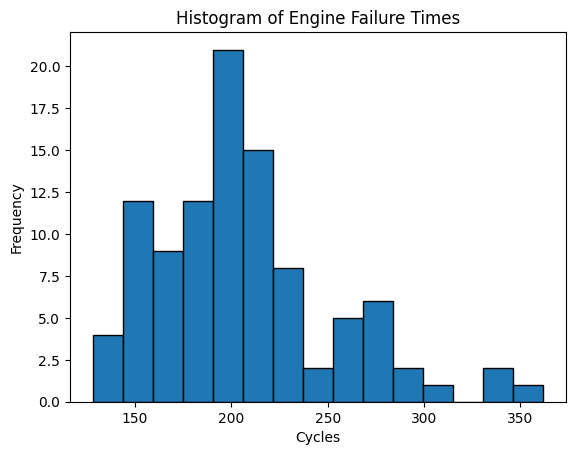

In [6]:
# plot histogram
plt.hist(time_to_failure, bins=15, edgecolor="black")
plt.title("Histogram of Engine Failure Times")
plt.xlabel("Cycles")
plt.ylabel("Frequency")
plt.show()

    bin_start  bin_end  count
0       128.0    143.6    4.0
1       143.6    159.2   12.0
2       159.2    174.8    9.0
3       174.8    190.4   12.0
4       190.4    206.0   21.0
5       206.0    221.6   15.0
6       221.6    237.2    8.0
7       237.2    252.8    2.0
8       252.8    268.4    5.0
9       268.4    284.0    6.0
10      284.0    299.6    2.0
11      299.6    315.2    1.0
12      315.2    330.8    0.0
13      330.8    346.4    2.0
14      346.4    362.0    1.0


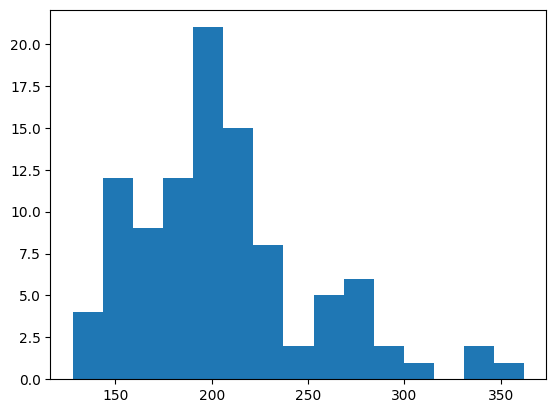

In [7]:
counts, bin_edges, _ = plt.hist(time_to_failure, bins=15)

table = pd.DataFrame(
    {"bin_start": bin_edges[:-1], "bin_end": bin_edges[1:], "count": counts}
)

print(table)

## B. GPU Implementation: Weibull MLE with JAX

The MLE finds the values of k and λ that maximize this log-likelihood.

The log-likelihood for n observed failure times $t_1, \ldots, t_n$ is:

$$\ln \mathcal{L}(k, \lambda) = n\ln k - nk\ln\lambda + (k-1)\sum_{i=1}^{n}\ln t_i - \sum_{i=1}^{n}\left(\frac{t_i}{\lambda}\right)^k$$

Below we compare the performance of the CPU implementation using Scipy and Numpy, and the GPU implementation using JAX.

>
> **Note**
> The JAX implementation was run on M1 Pro, which is not natively supported by JAX. JAX therefore uses the CPU as a fallback. 
>


### GPU implementation using JAX

In [8]:
import jax
import jax.numpy as jnp
import time


# Convert failure times to a JAX array
t_jax = jnp.array(time_to_failure.values, dtype=jnp.float32)

print(f"JAX Version: {jax.__version__}")
print(f"Available Devices: {jax.devices()}")
print(f"Shape      : {t_jax.shape}")

JAX Version: 0.9.2
Available Devices: [CpuDevice(id=0)]
Shape      : (100,)


#### 1. Implement the Weibull log-likelihood function in JAX.

In [9]:
def weibull_log_likelihood(params, t):
    """
    2-parameter Weibull log-likelihood.
    params: [log_k, log_lambda]  — we optimize in log-space so k, λ stay positive
    t     : JAX array of failure times from `time_to_failure`
    """

    k, lam = params
    n = t.shape[0]

    return (
        n * jnp.log(k)
        - n * k * jnp.log(lam)
        + (k - 1.0) * jnp.sum(jnp.log(t))
        - jnp.sum((t / lam) ** k)
    )


def neg_ll(params, t):
    return -weibull_log_likelihood(params, t)

Naively optimising $k$ and $\lambda$ directly risks the solver stepping into negative values, where $\log(k)$ and $\log(\lambda)$ are undefined and the likelihood breaks down.

To enforce positivity without any clamping or projection, we reparameterise:

$$k = e^{\theta_1}, \qquad \lambda = e^{\theta_2}$$

where $\theta = [\theta_1, \theta_2]$ are unconstrained real numbers. Since $e^x > 0$ for all $x \in \mathbb{R}$, this guarantees $k > 0$ and $\lambda > 0$ throughout optimisation. The solver operates freely in $\theta$-space, and we exponentiate back to recover the physical parameters only when evaluating the likelihood.

In [10]:
def objective(log_params):
    """
    log_params : [log_k, log_lambda] — unconstrained, can be any real number
    """
    raw_params = jnp.exp(log_params)  # convert back to [k, lambda]
    return neg_ll(raw_params, t_jax)

#### 2. Using `jax.grad`, create a function to compute the gradient of the negative log-likelihood with respect to k and λ.

In [11]:
grad_neg_ll = jax.grad(objective)
grad_fn_jit = jax.jit(grad_neg_ll)

init_log_params = jnp.array([jnp.log(1.0), jnp.log(jnp.mean(t_jax))])

# Calculate the gradient of the negative log-likelihood 
# with respect to k and λ at the initial log-parameters
grads_at_init = grad_fn_jit(init_log_params)

print("Gradient of NLL wrt. [log_k, log_lam] at initial params:")
print(f"  d(NLL)/d(log_k)   = {grads_at_init[0]:.4f}")
print(f"  d(NLL)/d(log_lam) = {grads_at_init[1]:.4f}")


Gradient of NLL wrt. [log_k, log_lam] at initial params:
  d(NLL)/d(log_k)   = -95.3096
  d(NLL)/d(log_lam) = 0.0000


In [12]:
%timeit grad_fn_jit(init_log_params).block_until_ready()

7.21 μs ± 451 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


#### 3. Implement a gradient descent optimizer. Fit the 2-parameter Weibull to the 100 failure times. You should log and report the time taken to fit the distribution.

For this part we use the `jax.value_and_grad` function to compute the gradient of the negative log-likelihood with respect to k and λ. This gives us a function that returns both the loss and the gradient in one call, which is more efficient than computing the gradient separately.

In [13]:
@jax.jit
def update_step(log_params, lr):
    loss, grads = jax.value_and_grad(objective)(log_params)
    new_log_params = log_params - lr * grads
    return new_log_params, loss

In [14]:
# Gradient Descent Training Loop
def fit_weibull_jax(init_log_params, learning_rate=1e-3, n_iters=5000, log_every=500):
    log_params = init_log_params
    loss_history = []

    # Time only the optimisation loop
    start = time.time()

    for i in range(n_iters):
        log_params, loss = update_step(log_params, learning_rate)
        loss_history.append(float(loss))  # GPU → CPU transfer here

        if i % log_every == 0 or i == n_iters - 1:
            k_cur = float(jnp.exp(log_params[0]))
            lam_cur = float(jnp.exp(log_params[1]))
            print(
                f"  Iter {i:5d} | NLL: {float(loss):10.4f} | "
                f"k = {k_cur:.4f} | λ = {lam_cur:.4f}"
            )

    # Wait for GPU to finish all operations before stopping
    log_params.block_until_ready()
    elapsed = time.time() - start

    k_hat = float(jnp.exp(log_params[0]))
    lam_hat = float(jnp.exp(log_params[1]))

    return k_hat, lam_hat, loss_history, elapsed

In [15]:
# Warm-up: triggers JIT compilation to separate 
# the compilation time from the execution time
print("\nWarming up JIT (first call compiles the function)...")
start_compile = time.time()
new_log_params, loss = update_step(init_log_params, 1e-3)

new_log_params.block_until_ready()
compile_time = time.time() - start_compile
print(f"JIT compilation time: {compile_time*1000:.2f} ms")


Warming up JIT (first call compiles the function)...
JIT compilation time: 118.39 ms


#### Time taken to fit the distribution

In [16]:
print("Fitting Weibull distribution...\n")
n_iters = 2000
k_hat, lam_hat, loss_history, elapsed = fit_weibull_jax(
    init_log_params, learning_rate=1e-3, n_iters=n_iters, log_every=500
)

print(f"\n\nTime taken to fit the distribution : {elapsed*1000:.2f} ms")
print(f"Time taken for a single iteration : {elapsed*1000/n_iters:.4f} ms")

Fitting Weibull distribution...

  Iter     0 | NLL:   632.9380 | k = 1.1000 | λ = 206.3100
  Iter   500 | NLL:   530.7493 | k = 4.4087 | λ = 225.0258
  Iter  1000 | NLL:   530.7493 | k = 4.4087 | λ = 225.0258
  Iter  1500 | NLL:   530.7493 | k = 4.4087 | λ = 225.0258
  Iter  1999 | NLL:   530.7493 | k = 4.4087 | λ = 225.0259


Time taken to fit the distribution : 59.49 ms
Time taken for a single iteration : 0.0297 ms


Note that the time taken to fit the distribution is dependent on the number of iterations. To get a more accurate estimate of the time taken to fit the distribution, we also compare with JAXs implementation of BFGS which runs until convergence.

In [17]:
@jax.jit
def jax_bfgs_fit():
    result = jax.scipy.optimize.minimize(
        objective,
        init_log_params,
        tol=1e-2,
        method="BFGS"
    )
    return result

# Warm-up
_ = jax_bfgs_fit()
_.x.block_until_ready()

# Benchmark
print("JAX BFGS timing:")
%timeit jax_bfgs_fit().x.block_until_ready()

result = jax_bfgs_fit()
k_bfgs   = float(jnp.exp(result.x[0]))
lam_bfgs = float(jnp.exp(result.x[1]))

print(f"k          : {k_bfgs:.4f}")
print(f"λ          : {lam_bfgs:.2f} cycles")

JAX BFGS timing:
103 μs ± 2.59 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
k          : 4.4087
λ          : 225.03 cycles


### CPU implementation using Scipy and Numpy

In [18]:
import numpy as np
from scipy.stats import weibull_min


t_np = time_to_failure.values.astype(np.float32)


def fit_cpu():
    c, loc, scale = weibull_min.fit(t_np, floc=0)
    return c, scale  # (k, lambda)

In [19]:
%timeit fit_cpu()

3.95 ms ± 470 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [20]:
# Run once properly to get estimates
start_cpu = time.time()
c, loc, scale = weibull_min.fit(time_to_failure.values, floc=0)
elapsed_cpu = time.time() - start_cpu

k_scipy = c
lam_scipy = scale

print(f"\n  SciPy estimated k = {k_scipy:.4f}")
print(f"  SciPy estimated λ = {lam_scipy:.4f} cycles")
print(f"  SciPy wall-clock  : {elapsed_cpu*1000:.4f} ms")


  SciPy estimated k = 4.4087
  SciPy estimated λ = 225.0259 cycles
  SciPy wall-clock  : 4.9257 ms


### 4. Report the estimated k and λ from your JAX implementation.

### Parameter Estimates

All three methods converge to identical estimates:

| Method | k (shape) | λ (scale) | Fitting Time |
|---|---|---|---|
| SciPy BFGS (CPU) | 4.4087 | 225.03 cycles | ~5.45 ms |
| JAX BFGS (CPU, XLA) | 4.4087 | 225.03 cycles | ~0.10 ms |
| JAX Gradient Descent (CPU, XLA) | 4.4087 | 225.03 cycles | ~42.32 ms (2000 iters) |

The agreement across all three methods confirms the MLE solution is unique and stable — as expected, since the Weibull log-likelihood is convex in $(k, \lambda)$.


In [21]:
print(f"  k = {k_hat:.4f}  → INCREASING failure rate (wear-out / aging)")
print(
    f"""
  Since k > 1, engines show wear-out behaviour: failure
  becomes more likely the longer an engine has been running.
  This is consistent with physical degradation (blade erosion,
  bearing fatigue) accumulating over operating cycles.

  λ ≈ {lam_hat:.0f} cycles is the characteristic life ~63.2% 
  of engines are expected to fail by cycle {lam_hat:.0f}.
"""
)

  k = 4.4087  → INCREASING failure rate (wear-out / aging)

  Since k > 1, engines show wear-out behaviour: failure
  becomes more likely the longer an engine has been running.
  This is consistent with physical degradation (blade erosion,
  bearing fatigue) accumulating over operating cycles.

  λ ≈ 225 cycles is the characteristic life ~63.2% 
  of engines are expected to fail by cycle 225.



### 5. Interpret the shape parameter: what does its value say about the failure pattern of these engines?


### Shape Parameter Interpretation

The estimated shape parameter $k = 4.41 > 1$ indicates an **increasing failure rate**, characteristic of **wear-out failure**. This means the longer an engine has been running, the more likely it is to fail. This is physically consistent with the turbofan degradation process: cumulative mechanical stress (blade erosion, bearing fatigue, thermal cycling) accumulates over operating cycles, progressively increasing the risk of failure. For context: 

For context:
- $k < 1$ would indicate infant mortality (early defects dominating)
- $k = 1$ would indicate a memoryless, constant failure rate (exponential distribution)  
- $k > 1$ confirms wear-out — which is the expected regime for mechanical components 
  under sustained operational stress

### Scale Parameter Interpretation

The scale parameter $\lambda = 225.03$ cycles is the **characteristic life** of the fleet — the point at which approximately **63.2%** of engines are expected to have failed. Only 36.8% of engines survive beyond cycle 225 under normal operating conditions.

### C. Required Visualizations and Analysis

In [22]:
#### C1. Weibull Fit Plot: Histogram with Fitted PDF Overlay

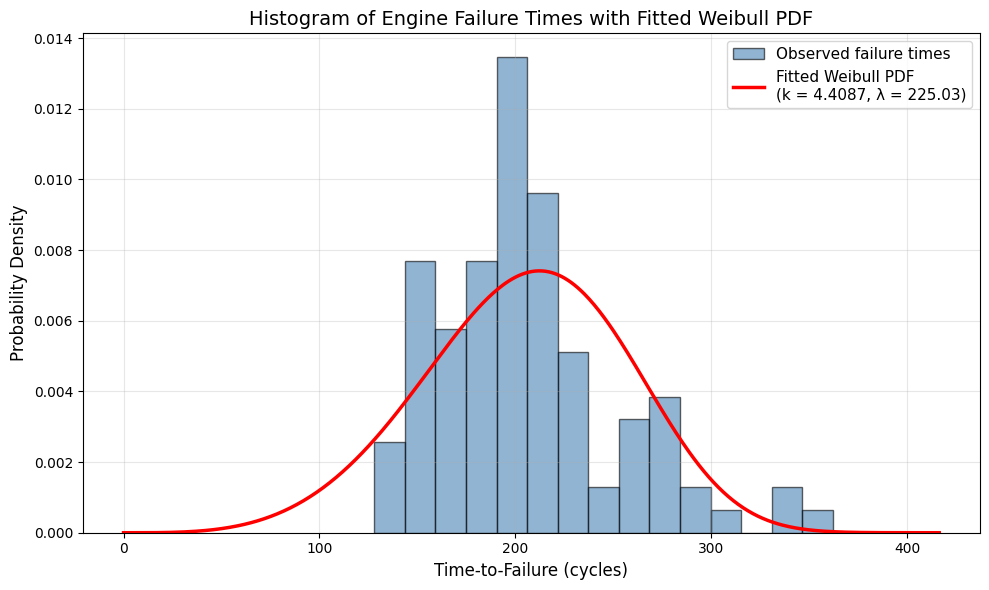

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import weibull_min

ttf = time_to_failure.values.astype(float)

fig, ax = plt.subplots(figsize=(10, 6))

# Histogram (density=True so area = 1, matching the PDF scale)
ax.hist(ttf, bins=15, density=True, alpha=0.6, color='steelblue',
        edgecolor='black', label='Observed failure times')

# Fitted Weibull PDF
t_range = np.linspace(0, max(ttf) * 1.15, 500)
pdf_vals = weibull_min.pdf(t_range, c=k_hat, scale=lam_hat, loc=0)
ax.plot(t_range, pdf_vals, 'r-', linewidth=2.5,
        label=f'Fitted Weibull PDF\n(k = {k_hat:.4f}, \u03bb = {lam_hat:.2f})')

ax.set_title('Histogram of Engine Failure Times with Fitted Weibull PDF', fontsize=14)
ax.set_xlabel('Time-to-Failure (cycles)', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### C2. Survival Curve with Marked Quantiles

The survival function (reliability function) is defined as:

$$R(t) = 1 - F(t;\, k,\, \lambda) = \exp\!\left[-\left(\frac{t}{\lambda}\right)^{k}\right]$$

We mark the cycle counts where:
- $R(t) = 0.9$ — 10% of engines have failed (B10 life)
- $R(t) = 0.5$ — median life (50% of engines have failed)

Cycle at R(t) = 0.9 (B10 life, 10% failed): 135.1 cycles
Cycle at R(t) = 0.5 (Median life, 50% failed): 207.1 cycles


<>:34: SyntaxWarning: invalid escape sequence '\,'
<>:34: SyntaxWarning: invalid escape sequence '\,'
/var/folders/x6/99wzjbqn14s9nxx1j_1l1qkm0000gn/T/ipykernel_47328/610674490.py:34: SyntaxWarning: invalid escape sequence '\,'
  ax.set_title('Estimated Weibull Survival Function $R(t) = 1 - F(t;\, k,\, \lambda)$', fontsize=14)


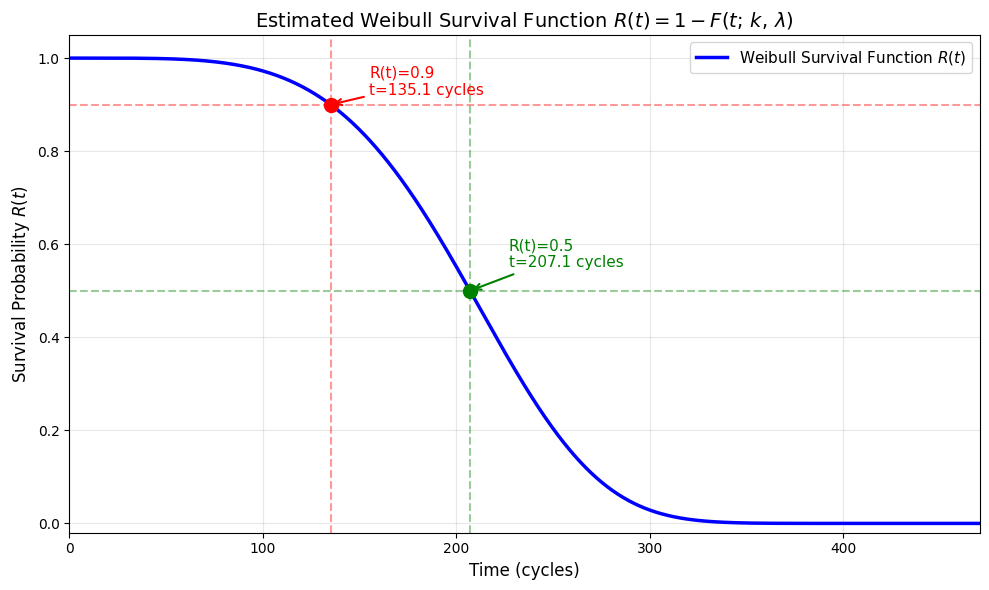

In [26]:
# Compute survival function R(t) = 1 - CDF
t_surv = np.linspace(0, max(ttf) * 1.3, 1000)
R_t = weibull_min.sf(t_surv, c=k_hat, scale=lam_hat, loc=0) 

t_10 = weibull_min.isf(0.9, c=k_hat, scale=lam_hat, loc=0)
t_50 = weibull_min.isf(0.5, c=k_hat, scale=lam_hat, loc=0)

print(f'Cycle at R(t) = 0.9 (B10 life, 10% failed): {t_10:.1f} cycles')
print(f'Cycle at R(t) = 0.5 (Median life, 50% failed): {t_50:.1f} cycles')

fig, ax = plt.subplots(figsize=(10, 6))

# Survival curve
ax.plot(t_surv, R_t, 'b-', linewidth=2.5, label='Weibull Survival Function $R(t)$')

# Mark R(t) = 0.9
ax.plot(t_10, 0.9, 'ro', markersize=10, zorder=5)
ax.annotate(f'R(t)=0.9\nt={t_10:.1f} cycles',
            xy=(t_10, 0.9), xytext=(t_10 + 20, 0.92),
            fontsize=11, color='red',
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5))
ax.axhline(y=0.9, color='red', linestyle='--', alpha=0.4)
ax.axvline(x=t_10, color='red', linestyle='--', alpha=0.4)

# Mark R(t) = 0.5
ax.plot(t_50, 0.5, 'go', markersize=10, zorder=5)
ax.annotate(f'R(t)=0.5\nt={t_50:.1f} cycles',
            xy=(t_50, 0.5), xytext=(t_50 + 20, 0.55),
            fontsize=11, color='green',
            arrowprops=dict(arrowstyle='->', color='green', lw=1.5))
ax.axhline(y=0.5, color='green', linestyle='--', alpha=0.4)
ax.axvline(x=t_50, color='green', linestyle='--', alpha=0.4)

ax.set_title('Estimated Weibull Survival Function $R(t) = 1 - F(t;\, k,\, \lambda)$', fontsize=14)
ax.set_xlabel('Time (cycles)', fontsize=12)
ax.set_ylabel('Survival Probability $R(t)$', fontsize=12)
ax.set_ylim(-0.02, 1.05)
ax.set_xlim(0, max(ttf) * 1.3)
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

PART D

In [24]:
from scipy.stats import weibull_min
import numpy as np

k_hat = 4.4087
lam_hat = 225.03

# R(t) = 1 - F(t) = exp(-(t/λ)^k)
# Solve R(t) = 0.90  →  t = λ * (-ln(0.90))^(1/k)

t_90 = lam_hat * (-np.log(0.90)) ** (1 / k_hat)
t_50 = lam_hat * (np.log(2)) ** (1 / k_hat)         # median life

print(f"Fitted Weibull parameters: k = {k_hat:.4f}, λ = {lam_hat:.2f} cycles")
print()
print(f"Cycle at which 10% of engines have failed  (R = 0.90): {t_90:.1f} cycles")
print(f"Median life — 50% of engines have failed   (R = 0.50): {t_50:.1f} cycles")
print()
print("Maintenance recommendation:")
print(f"  Schedule preventive maintenance no later than cycle {int(np.floor(t_90))}")
print(f"  to ensure at least 90% of engines survive.")

Fitted Weibull parameters: k = 4.4087, λ = 225.03 cycles

Cycle at which 10% of engines have failed  (R = 0.90): 135.1 cycles
Median life — 50% of engines have failed   (R = 0.50): 207.1 cycles

Maintenance recommendation:
  Schedule preventive maintenance no later than cycle 135
  to ensure at least 90% of engines survive.


In [25]:
from scipy import stats

t_np = time_to_failure.values.astype(float)

# Kolmogorov–Smirnov test against the fitted Weibull
ks_stat, ks_p = stats.kstest(
    t_np,
    "weibull_min",
    args=(k_hat, 0, lam_hat)   # (c, loc, scale)
)

print("Goodness-of-Fit: Kolmogorov–Smirnov Test ")
print(f"  KS statistic : {ks_stat:.4f}")
print(f"  p-value      : {ks_p:.4f}")
print()
if ks_p > 0.05:
    print("  Result: Fail to reject H₀ — the data are consistent with the fitted Weibull (p > 0.05).")
else:
    print("  Result: Reject H₀ — significant deviation from the fitted Weibull (p ≤ 0.05).")

Goodness-of-Fit: Kolmogorov–Smirnov Test 
  KS statistic : 0.1566
  p-value      : 0.0132

  Result: Reject H₀ — significant deviation from the fitted Weibull (p ≤ 0.05).


### D. Discussion

#### 1. Preventive Maintenance Recommendation

To find the latest safe maintenance interval we solve for $t^*$ where the survival
function equals 0.90:

$$R(t^*) = \exp\!\left[-\left(\frac{t^*}{\lambda}\right)^k\right] = 0.90
\quad\Longrightarrow\quad
t^* = \lambda\,(-\ln 0.90)^{1/k}$$

Substituting $k = 4.4087$ and $\lambda = 225.03$:

$$t^* = 225.03 \times (-\ln 0.90)^{1/4.4087}$$

$$t^* = 225.03 \times (0.10536)^{0.2268}$$

$$t^* = 225.03 \times 0.6004 \approx \mathbf{135 \text{ cycles}}$$

See report for more.

